Published on November 13, 2025. By Marília Prata, mpwolke

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

#Two lines Required to Plot Plotly
import plotly.io as pio
pio.renderers.default = 'iframe'

import plotly.graph_objs as go
import plotly.offline as py
import plotly.express as px

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vesuvius-challenge-surface-detection/train.csv
/kaggle/input/vesuvius-challenge-surface-detection/test.csv
/kaggle/input/vesuvius-challenge-surface-detection/train_images/1448189335.tif
/kaggle/input/vesuvius-challenge-surface-detection/train_images/1255754809.tif
/kaggle/input/vesuvius-challenge-surface-detection/train_images/3637340207.tif
/kaggle/input/vesuvius-challenge-surface-detection/train_images/3070061281.tif
/kaggle/input/vesuvius-challenge-surface-detection/train_images/215093936.tif
/kaggle/input/vesuvius-challenge-surface-detection/train_images/865516044.tif
/kaggle/input/vesuvius-challenge-surface-detection/train_images/196724516.tif
/kaggle/input/vesuvius-challenge-surface-detection/train_images/2961522369.tif
/kaggle/input/vesuvius-challenge-surface-detection/train_images/3090197578.tif
/kaggle/input/vesuvius-challenge-surface-detection/train_images/840310891.tif
/kaggle/input/vesuvius-challenge-surface-detection/train_images/2579374491.tif
/kaggle/input/

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTHOBTVTporsrFvGSD7809EQMUJfdpitL5axQ&s)Facebook

## About Competition: Villa dei Papiri

"Before we can recover what’s written between the lines, we first need to find the lines. You’ll work with CT scans from the Villa dei Papiri to train a model that follows the scroll’s surface, one of the trickiest and most essential parts of virtually unwrapping the text."

https://www.kaggle.com/competitions/vesuvius-challenge-surface-detection/overview

"Your challenge in this competition is to **detect and segment layers of papyrus in 3D imagery**. This will help researchers virtually unroll the ancient scrolls from Herculaneum and ultimately recover the original texts."

"This competition uses a hidden test set. When your submitted notebook is scored, the actual test data will be made available to your notebook. Expect to see roughly 120 volumes in the hidden test set."

https://www.kaggle.com/competitions/vesuvius-challenge-surface-detection/data

"The **Villa of the Papyri** (Italian: Villa dei Papiri) was an ancient Roman villa in Herculaneum, in what is now Ercolano, southern Italy. It is named after its unique **library of papyri scrolls**, discovered in 1750. The Villa was considered to be one of the most luxurious houses in all of Herculaneum and in the Roman world."

https://en.wikipedia.org/wiki/Villa_of_the_Papyri

## Competition Citation:

@misc{vesuvius-challenge-surface-detection,
    author = {Sean Johnson and David Josey and Elian Rafael Dal Prà and Hendrik Schilling and Youssef Nader and Johannes Rudolph and Forrest McDonald and Paul Henderson and Giorgio Angelotti and Sohier Dane and María Cruz},
    
    title = {Vesuvius Challenge - Surface Detection},
    year = {2025},
    
    howpublished = {\url{https://kaggle.com/competitions/vesuvius-challenge-surface-detection}},
    note = {Kaggle}
}

## Import Libraries

In [2]:
import math
import time
import datetime
import glob

import cv2
import matplotlib.pyplot as plt
import seaborn as sn
import json
import tifffile as tiff
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib_venn import venn2_unweighted

In [3]:
#Code by Georgii Kostiuchik https://www.kaggle.com/code/georgiikostiuchik/hubmap-exploratory-data-analysis

train_images = glob.glob('/kaggle/input/vesuvius-challenge-surface-detection/train_images/*.tif')
test_images = glob.glob('/kaggle/input/vesuvius-challenge-surface-detection/test_images/*.tif')

train_images = list(map(lambda x: os.path.basename(x), train_images))
test_images = list(map(lambda x: os.path.basename(x), test_images))

## The only tif file on test_images

In [6]:
#Code by Georgii Kostiuchik https://www.kaggle.com/code/georgiikostiuchik/hubmap-exploratory-data-analysis

# open and resize image
image = cv2.imread('/kaggle/input/vesuvius-challenge-surface-detection/test_images/1407735.tif')
image_resize = cv2.resize(image,(image.shape[1]//10,image.shape[0]//10), interpolation = cv2.INTER_CUBIC)

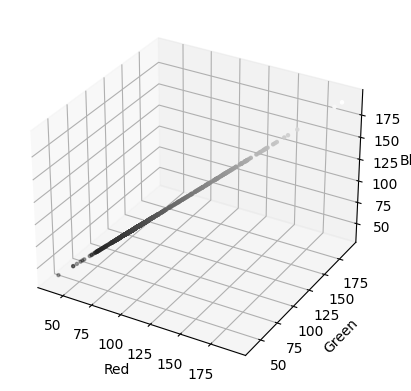

In [7]:
#Code by Georgii Kostiuchik https://www.kaggle.com/code/georgiikostiuchik/hubmap-exploratory-data-analysis

# calculate colors
pixel_colors = image_resize.reshape((np.shape(image_resize)[0]*np.shape(image_resize)[1], 3))
norm = colors.Normalize(vmin=-1.,vmax=1.)
norm.autoscale(pixel_colors)
pixel_colors = norm(pixel_colors).tolist()

# split channels
b, g, r = cv2.split(image_resize)

# scatter plot
fig = plt.figure()
axis = fig.add_subplot(1, 1, 1, projection='3d')
axis.scatter(r.flatten(), g.flatten(), b.flatten(), facecolors=pixel_colors, marker='.')
axis.set_xlabel('Red')
axis.set_ylabel('Green')
axis.set_zlabel('Blue')
plt.show()

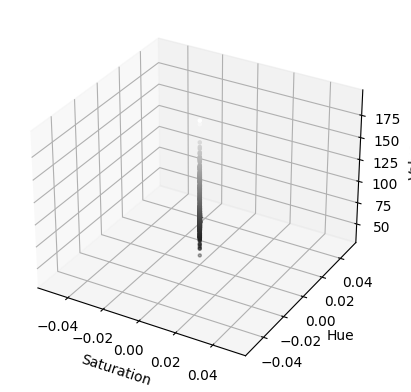

In [8]:
#Code by Georgii Kostiuchik https://www.kaggle.com/code/georgiikostiuchik/hubmap-exploratory-data-analysis

# convert to hsv
hsv_image = cv2.cvtColor(image_resize, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv_image)

# scatter plot
fig = plt.figure()
axis = fig.add_subplot(1, 1, 1, projection='3d')
axis.scatter(s.flatten(), h.flatten(), v.flatten(), facecolors=pixel_colors, marker='.')
axis.set_xlabel('Saturation')
axis.set_ylabel('Hue')
axis.set_zlabel('Value')
plt.show()

### Unfortunately, it didn't help much

In [9]:
DATA_PATH = "../input/vesuvius-challenge-surface-detection/"

In [10]:
image_paths = sorted(glob.glob(os.path.join(DATA_PATH, 'train_images/*.tif')))

## len (number of images)

In [11]:
print(f"Number of images: {len(image_paths)}")

Number of images: 806


## Display some images

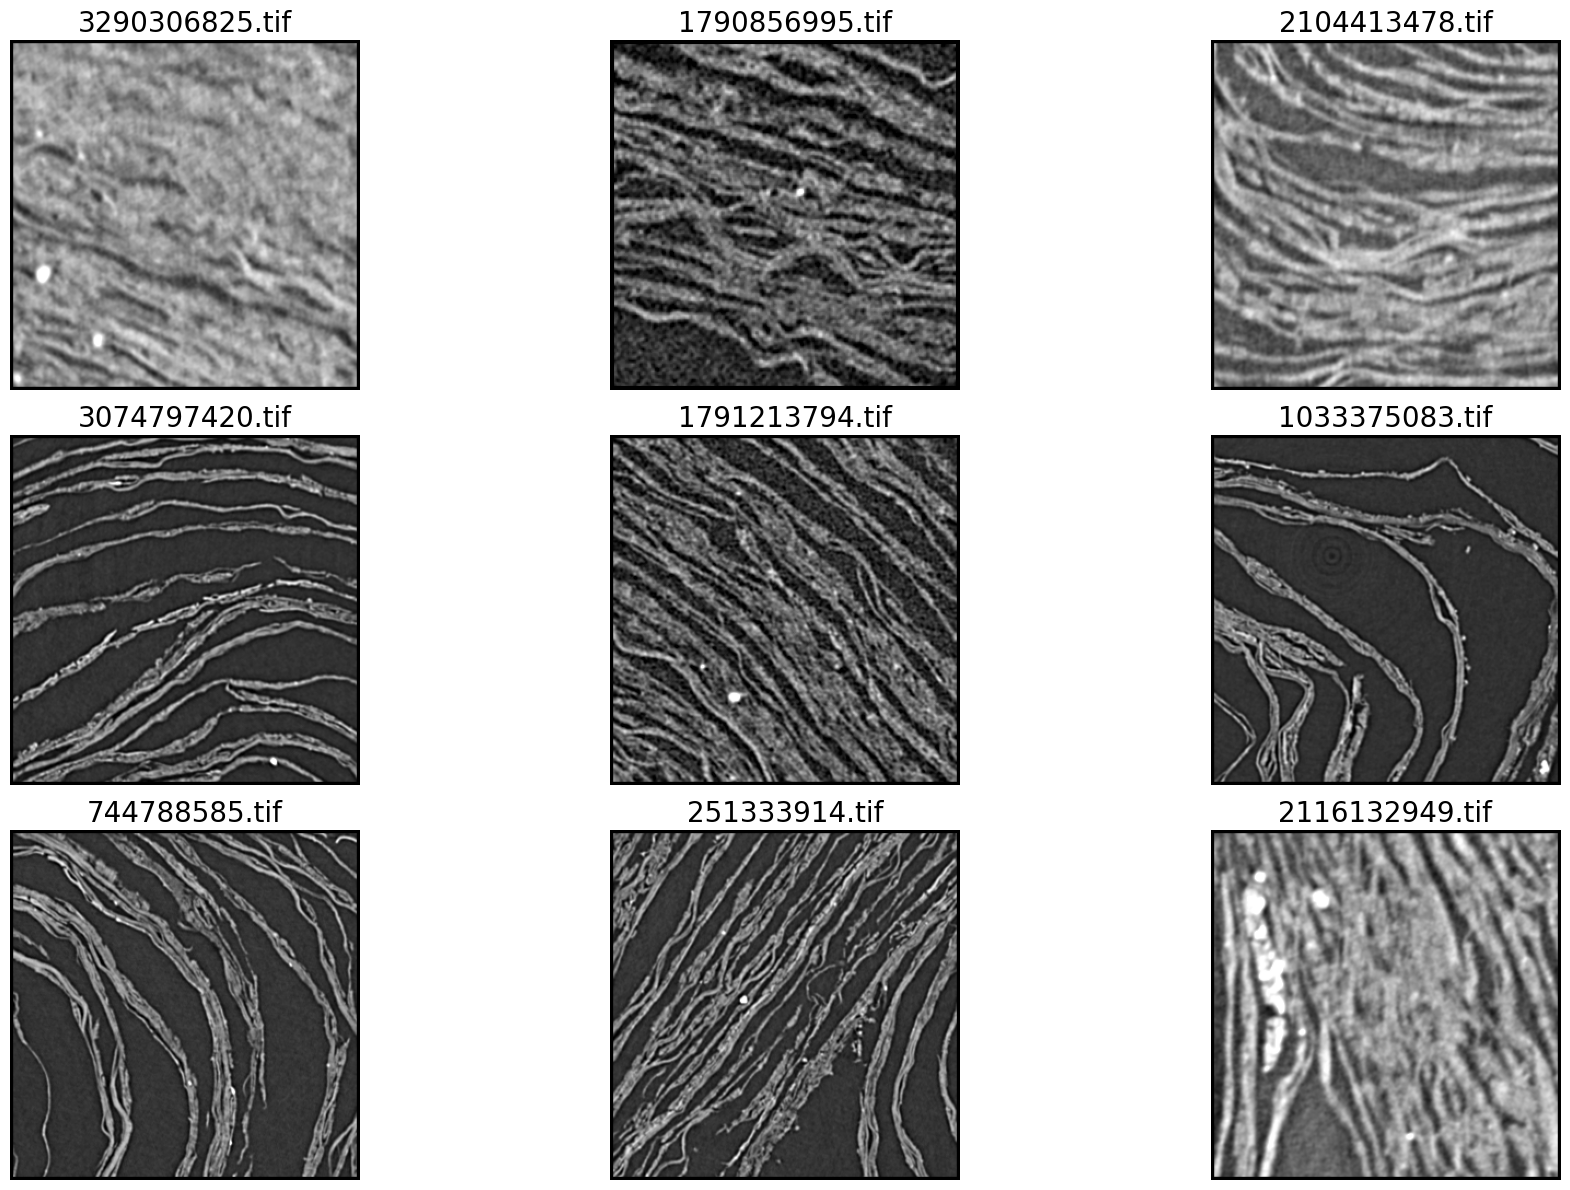

In [17]:
#By Ruhul Amin https://www.kaggle.com/code/ruhul20/cctv-weapon-detection-yolo11s/notebook

from pathlib import Path
import random

train_images_dir = Path("/kaggle/input/vesuvius-challenge-surface-detection/train_images/")

image_files = list(train_images_dir.glob("*.tif"))

sample_files = random.sample(image_files, min(9, len(image_files)))

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_files):
    img = cv2.imread(str(img_path))                  
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)       
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name, fontsize=20)

plt.tight_layout()
plt.show()

## Load csv files. No submission file, just train and test.

In [12]:
train = pd.read_csv('/kaggle/input/vesuvius-challenge-surface-detection/train.csv')
test = pd.read_csv('/kaggle/input/vesuvius-challenge-surface-detection/test.csv')

In [13]:
train.tail()

,id,scroll_id
801,4256996840,34117
802,4273576431,34117
803,4280519539,34117
804,4288082812,26002
805,4293224556,34117


In [14]:
test.tail()

,id,scroll_id
0,1407735,26002


## And, the only test tif file.

Vesuvius Surface Detection test image


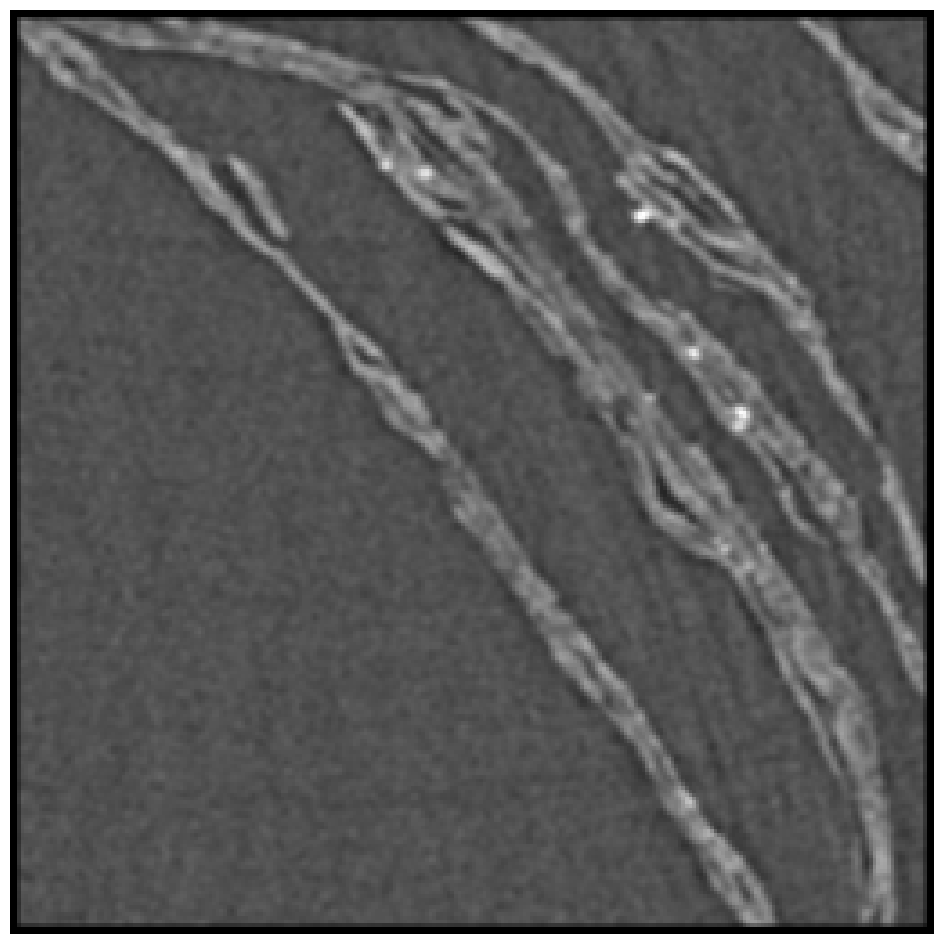

In [5]:
def plotImages(tools,directory):
    print(tools)
    multipleImages = glob.glob(directory)
    plt.rcParams['figure.figsize'] = (12, 12) #Original is 15,15. Since we have 18 veggies I decreased the size
    plt.subplots_adjust(wspace=0, hspace=0)
    i_ = 0
    for l in multipleImages[:1]:
        im = cv2.imread(l)
        im = cv2.resize(im, (256, 256)) 
        plt.subplot(1, 1, i_+1) #.set_title(l)
        plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); plt.axis('off')
        i_ += 1

plotImages("Vesuvius Surface Detection test image","../input/vesuvius-challenge-surface-detection/test_images/**")

## Since it's a Surface Detection, I could't read anything till now.

### AI deciphered text on ancient scrolls

"The Herculaneum Papyri, an ancient scroll fossilized by the Mount Vesuvius eruption in 79 AD, is now decipherable, thanks to an open-source AI project."

"Computer science student Luke Farritor "became the first person in two millennia to see an entire word from within an unopened scroll this August," according to the Vesuvius Challenge, which offers cash prizes for those who can figure out what the scroll says. The contest was created to accelerate the research and discovery of the scrolls after University of Kentucky researchers led by Dr. Brent Seales used computer vision to virtually "open" the scrolls in 2015."

"Farritor was awarded 40,000 for discovering the first word. Another contestant, biorobotics student Youssef Nader, used another method involving an unsupervised pre-training model on the data, then fine-tuning the data on the "fragment labels." Nader found letters possibly forming the words "**achieving"** and "**similar**"; he was awarded 10,000 for his discovery."

https://www.instagram.com/p/Cyo10dSrTMH/

## The real gains are still ahead of us.

"Some of the papyrus topics discussed by Philodemus and Epicurus are still relevant. “The basic questions Epicurus was asking are the ones that face us all as humans. How do we live a good life? How do we avoid pain?” But **“the real gains are still ahead of us**”
 
“What’s so exciting is less what this scroll says, but that the decipherment of this scroll bodes well for the decipherment of the hundreds of scrolls that they had previously given up on."

https://www.scientificamerican.com/article/ai-unravels-ancient-roman-scrolls-charred-by-volcano/#:~:text=Text%20from%20the%20Herculaneum%20scroll,been%20unseen%20for%202%2C000%20years.&text=A%20team%20of%20student%20researchers,the%20eruption%20of%20Mount%20Vesuvius.

#Acknowledgements:

Ihelon https://www.kaggle.com/code/ihelon/illustrations-kumapi390-eda

Georgii Kostiuchik https://www.kaggle.com/code/georgiikostiuchik/hubmap-exploratory-data-analysis

Ruhul Amin https://www.kaggle.com/code/ruhul20/cctv-weapon-detection-yolo11s/notebook